In [2]:
# === CELL 1 ===
import pandas as pd
import numpy as np

df = pd.read_csv(r"C:\Users\hkana\Downloads\sbom-cra-research\results\master_results.csv")

ALL_CHECKS = ['A1','A2','A3','A4','A5','A6','A7','A8','A9','A10','A11','A12','A13',
              'B1','B2','B3','B4','C1','C2']

# NTIA-equivalent requirements
NTIA_EQUIV = ['A1','A2','A3','A4','A5','A6','A7','A12','A13']

# CRA-specific obligations
CRA_SPECIFIC = ['A8','B2','C1','C2']

# General SBOM quality checks
QUALITY_GENERAL = ['A10','A11','B4']

# Conditional-on-presence checks
CONDITIONAL_ON_PRESENCE = ['A9','B1']

print(f"Total SBOMs: {len(df)}")
print(f"Unique tools: {df['tool'].nunique()}")

Total SBOMs: 5000
Unique tools: 54


In [3]:
# === CELL 2 ===
# Use top 8 tools (covers ~96% of corpus), group the rest as "Other"
TOP_N = 8
top_tools = df['tool'].value_counts().head(TOP_N).index.tolist()

df['tool_grouped'] = df['tool'].apply(lambda t: t if t in top_tools else 'Other')

print("Tools included in breakdown:")
for t in top_tools:
    print(f"  {t}: {(df['tool']==t).sum()} files")
print(f"  Other (46 tools): {(df['tool_grouped']=='Other').sum()} files")

Tools included in breakdown:
  cdxgen: 1348 files
  Node.js module: 917 files
  cyclonedx-php-composer: 623 files
  cyclonedx-gomod: 502 files
  syft: 445 files
  unknown: 346 files
  Gemnasium: 239 files
  Github Extractor: 209 files
  Other (46 tools): 371 files


In [4]:
# === CELL 3 ===
def pass_rate(series):
    """Pass rate excluding SKIP."""
    scored = series[series.isin(['PASS','PARTIAL','FAIL'])]
    if len(scored) == 0:
        return np.nan
    return (scored == 'PASS').mean() * 100

matrix = pd.DataFrame(index=top_tools + ['Other'], columns=ALL_CHECKS, dtype=float)

for tool in top_tools + ['Other']:
    subset = df[df['tool_grouped'] == tool]
    for check in ALL_CHECKS:
        matrix.loc[tool, check] = pass_rate(subset[f'{check}_result'])

matrix_rounded = matrix.round(1)
print(matrix_rounded)

matrix_rounded.to_csv(r"C:\Users\hkana\Downloads\sbom-cra-research\results\tool_check_matrix.csv")

                           A1     A2    A3     A4     A5     A6    A7    A8  \
cdxgen                  100.0   99.9   1.6   99.9   32.9  100.0  83.1   0.1   
Node.js module          100.0   99.7   3.4  100.0   13.2  100.0  55.4   0.0   
cyclonedx-php-composer  100.0  100.0   0.0   98.6  100.0  100.0  51.4   0.0   
cyclonedx-gomod         100.0   38.0   0.0  100.0  100.0  100.0  56.2   0.0   
syft                     99.6   79.1  15.1   41.8   49.0  100.0  99.8  34.8   
unknown                 100.0   88.3   2.0   69.4    4.9   93.6  32.8   0.0   
Gemnasium               100.0  100.0   0.0   99.6    9.6  100.0  99.6   0.0   
Github Extractor        100.0  100.0  20.6  100.0    0.0  100.0  50.7   0.0   
Other                   100.0   72.5   5.7   67.1   83.3  100.0  79.0   4.0   

                           A9   A10   A11    A12    A13     B1    B2    B3  \
cdxgen                  100.0   8.8   4.1  100.0  100.0  100.0   2.1  65.7   
Node.js module            NaN   4.9   5.9  100.0   99

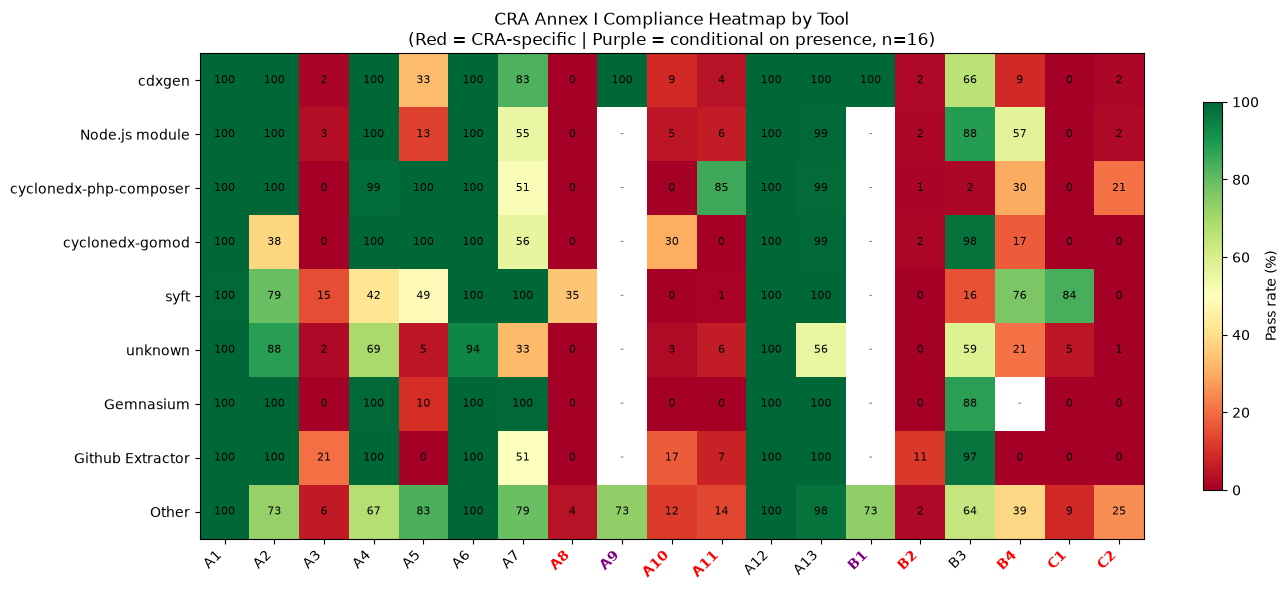

In [5]:
# === CELL 4 ===
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 6))

im = ax.imshow(matrix.values.astype(float), cmap='RdYlGn', vmin=0, vmax=100, aspect='auto')

ax.set_xticks(range(len(ALL_CHECKS)))
ax.set_xticklabels(ALL_CHECKS, rotation=45, ha='right')
ax.set_yticks(range(len(matrix.index)))
ax.set_yticklabels(matrix.index)

for i in range(len(matrix.index)):
    for j in range(len(ALL_CHECKS)):
        val = matrix.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.0f}', ha='center', va='center',
                    color='black', fontsize=8)
        else:
            ax.text(j, i, '-', ha='center', va='center', color='gray', fontsize=8)

for j, check in enumerate(ALL_CHECKS):
    if check in CRA_SPECIFIC:
        ax.get_xticklabels()[j].set_color('red')
        ax.get_xticklabels()[j].set_fontweight('bold')
    elif check in CONDITIONAL_ON_PRESENCE:
        ax.get_xticklabels()[j].set_color('purple')
        ax.get_xticklabels()[j].set_fontweight('bold')

ax.set_title("CRA Annex I Compliance Heatmap by Tool\n(Red = CRA-specific | Purple = conditional on presence, n=16)")
fig.colorbar(im, label='Pass rate (%)', shrink=0.8)
plt.tight_layout()
plt.savefig(r"C:\Users\hkana\Downloads\sbom-cra-research\results\failure_heatmap.png", dpi=200, bbox_inches='tight')
plt.show()

In [6]:
# === CELL 5 ===
ntia_avg = df[[f'{c}_result' for c in NTIA_EQUIV]].apply(
    lambda col: pass_rate(col)
).mean()

cra_avg = df[[f'{c}_result' for c in CRA_SPECIFIC]].apply(
    lambda col: pass_rate(col)
).mean()

conditional_avg = df[[f'{c}_result' for c in CONDITIONAL_ON_PRESENCE]].apply(
    lambda col: pass_rate(col)
)

print(f"NTIA-equivalent average pass rate : {ntia_avg:.1f}%")
print(f"CRA-specific average pass rate    : {cra_avg:.1f}%")
print(f"Compliance gap                    : {ntia_avg - cra_avg:.1f} percentage points")
print(f"\nConditional-on-presence checks (n=16 each):")
print(conditional_avg)

NTIA-equivalent average pass rate : 77.0%
CRA-specific average pass rate    : 11.7%
Compliance gap                    : 65.4 percentage points

Conditional-on-presence checks (n=16 each):
A9_result    75.0
B1_result    75.0
dtype: float64


In [7]:
# === CELL 6 ===
fmt_matrix = pd.DataFrame(index=df['format'].unique(), columns=ALL_CHECKS, dtype=float)

for fmt in df['format'].unique():
    subset = df[df['format'] == fmt]
    for check in ALL_CHECKS:
        fmt_matrix.loc[fmt, check] = pass_rate(subset[f'{check}_result'])

print(fmt_matrix.round(1))
fmt_matrix.round(1).to_csv(r"C:\Users\hkana\Downloads\sbom-cra-research\results\format_check_matrix.csv")

                   A1    A2    A3    A4    A5     A6    A7    A8    A9  A10  \
CycloneDX-JSON  100.0  91.2   2.6  93.0  45.1   99.5  69.4   0.4  75.0  9.0   
CycloneDX-XML   100.0  91.5   0.0  76.4   0.0  100.0  31.2   0.0   NaN  1.8   
SPDX-JSON       100.0  52.4  26.7  61.2  97.8  100.0  97.1  56.8   NaN  0.0   

                 A11    A12    A13    B1   B2    B3    B4    C1   C2  
CycloneDX-JSON  16.1  100.0   99.4  75.0  2.3  64.5  36.8   6.9  6.1  
CycloneDX-XML    0.0  100.0   52.9   NaN  0.0  62.7   NaN   3.5  0.0  
SPDX-JSON        4.8  100.0  100.0   NaN  3.0  25.6  65.4  39.6  0.0  


In [8]:
# === CELL 7 ===
overall_rates = {}
for check in ALL_CHECKS:
    overall_rates[check] = pass_rate(df[f'{check}_result'])

ranking = pd.Series(overall_rates).sort_values()
print("Checks ranked by failure rate (lowest pass rate first):")
print(ranking.round(1))

Checks ranked by failure rate (lowest pass rate first):
B2       2.2
A8       3.4
A3       3.9
C2       5.4
A10      8.2
C1       8.5
A11     14.9
B4      39.0
A5      45.1
B3      62.6
A7      68.5
B1      75.0
A9      75.0
A2      89.0
A4      90.7
A13     96.5
A6      99.6
A1     100.0
A12    100.0
dtype: float64


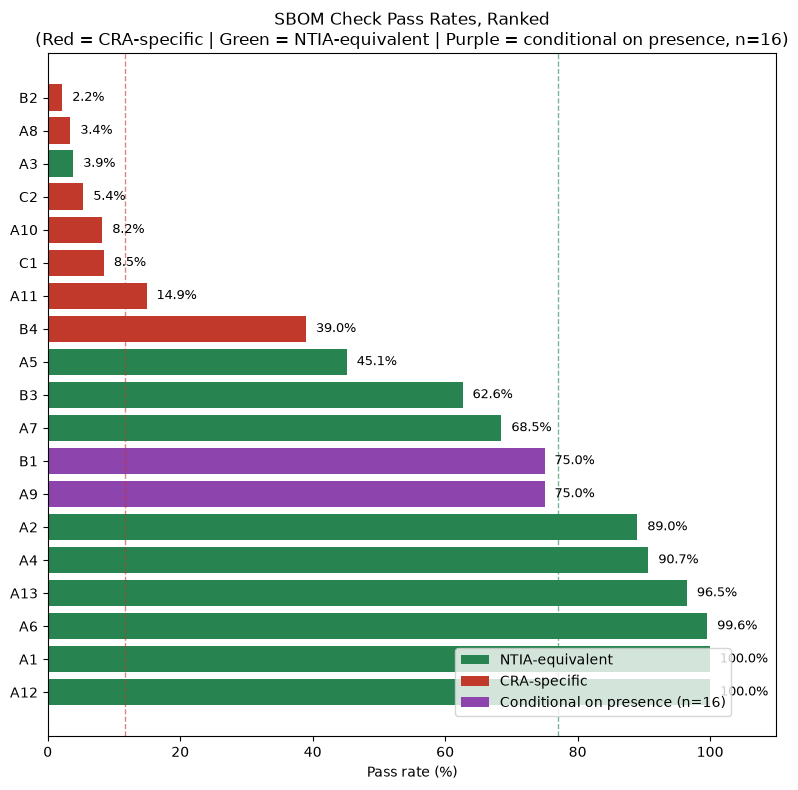

In [9]:
# === CELL 8 ===
from matplotlib.patches import Patch

ranking_sorted = ranking.sort_values()

def get_color(check):
    if check in CRA_SPECIFIC:
        return '#c0392b'
    elif check in CONDITIONAL_ON_PRESENCE:
        return '#8e44ad'
    else:
        return '#27834f'

colors = [get_color(c) for c in ranking_sorted.index]

fig, ax = plt.subplots(figsize=(8, 8))
bars = ax.barh(ranking_sorted.index, ranking_sorted.values, color=colors)
ax.invert_yaxis()

for bar, val in zip(bars, ranking_sorted.values):
    ax.text(val + 1.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)

ax.set_xlim(0, 110)
ax.set_xlabel('Pass rate (%)')
ax.set_title('SBOM Check Pass Rates, Ranked\n(Red = CRA-specific | Green = NTIA-equivalent | Purple = conditional on presence, n=16)')

legend_handles = [
    Patch(facecolor='#27834f', label='NTIA-equivalent'),
    Patch(facecolor='#c0392b', label='CRA-specific'),
    Patch(facecolor='#8e44ad', label='Conditional on presence (n=16)')
]
ax.legend(handles=legend_handles, loc='center left', bbox_to_anchor=(0.55, 0.08))

ax.axvline(x=ntia_avg, color='#27834f', linestyle='--', linewidth=1, alpha=0.6)
ax.axvline(x=cra_avg, color='#c0392b', linestyle='--', linewidth=1, alpha=0.6)

plt.tight_layout()
plt.savefig(r"C:\Users\hkana\Downloads\sbom-cra-research\results\check_ranking_bar_v2.png", dpi=200, bbox_inches='tight')
plt.show()

In [10]:
# === CELL 9 ===
a8_pass = df[df['A8_result'] == 'PASS']

structured = a8_pass['A8_detail'].str.contains('vulnerability entries declared', na=False).sum()
ref_only   = a8_pass['A8_detail'].str.contains('SECURITY externalRefs found', na=False).sum()

print(f"A8 PASS total: {len(a8_pass)} ({len(a8_pass)/len(df)*100:.1f}% of corpus)")
print(f"  Structured CycloneDX vulnerabilities[] : {structured} ({structured/len(df)*100:.2f}% of corpus)")
print(f"  SPDX SECURITY externalRef only          : {ref_only} ({ref_only/len(df)*100:.2f}% of corpus)")

A8 PASS total: 171 (3.4% of corpus)
  Structured CycloneDX vulnerabilities[] : 16 (0.32% of corpus)
  SPDX SECURITY externalRef only          : 155 (3.10% of corpus)


In [3]:
# === CELL 10: Wilson 95% Confidence Intervals ===
from scipy import stats
import math

def wilson_ci(n_pass, n_total, confidence=0.95):
    """Wilson score interval for a proportion."""
    if n_total == 0:
        return (np.nan, np.nan)
    p = n_pass / n_total
    z = stats.norm.ppf(1 - (1 - confidence) / 2)
    denom = 1 + z**2 / n_total
    centre = (p + z**2 / (2 * n_total)) / denom
    margin = (z * math.sqrt(p * (1 - p) / n_total + z**2 / (4 * n_total**2))) / denom
    return (max(0, (centre - margin) * 100), min(100, (centre + margin) * 100))

ci_rows = []
for check in ALL_CHECKS:
    col = df[f'{check}_result']
    scored = col[col.isin(['PASS', 'PARTIAL', 'FAIL'])]
    n_total = len(scored)
    n_pass  = (scored == 'PASS').sum()
    rate    = n_pass / n_total * 100 if n_total > 0 else np.nan
    lo, hi  = wilson_ci(n_pass, n_total)
    group   = ('NTIA' if check in NTIA_EQUIV
               else 'CRA' if check in CRA_SPECIFIC
               else 'Conditional')
    ci_rows.append({'Check': check, 'Group': group,
                    'N_scored': n_total, 'N_pass': n_pass,
                    'Pass_rate': round(rate, 1),
                    'CI_lower': round(lo, 1),
                    'CI_upper': round(hi, 1)})

ci_df = pd.DataFrame(ci_rows)
print(ci_df.to_string(index=False))
ci_df.to_csv(r"C:\Users\hkana\Downloads\sbom-cra-research\results\wilson_cis.csv", index=False)
print("\n--- KEY FIGURES FOR PAPER ---")
print(f"NTIA avg: {ci_df[ci_df.Group=='NTIA']['Pass_rate'].mean():.1f}%")
print(f"CRA avg:  {ci_df[ci_df.Group=='CRA']['Pass_rate'].mean():.1f}%")
# Special attention: A9 and B1 at n=16
for check in ['A9', 'B1']:
    row = ci_df[ci_df.Check == check].iloc[0]
    print(f"{check}: {row.Pass_rate:.1f}% (95% CI: {row.CI_lower:.1f}%–{row.CI_upper:.1f}%, n={row.N_scored})")

Check       Group  N_scored  N_pass  Pass_rate  CI_lower  CI_upper
   A1        NTIA      4850    4848      100.0      99.8     100.0
   A2        NTIA      4850    4317       89.0      88.1      89.9
   A3        NTIA      4850     187        3.9       3.3       4.4
   A4        NTIA      4850    4398       90.7      89.8      91.5
   A5        NTIA      4999    2257       45.1      43.8      46.5
   A6        NTIA      4999    4977       99.6      99.3      99.7
   A7        NTIA      4999    3424       68.5      67.2      69.8
   A8         CRA      4999     171        3.4       3.0       4.0
   A9 Conditional        16      12       75.0      50.5      89.8
  A10 Conditional      4850     400        8.2       7.5       9.1
  A11 Conditional      4850     724       14.9      14.0      16.0
  A12        NTIA      4999    4999      100.0      99.9     100.0
  A13        NTIA      4999    4824       96.5      96.0      97.0
   B1 Conditional        16      12       75.0      50.5      

In [4]:
# === CELL 11: Median and range within each group ===
for group_name, group_checks in [('NTIA-equivalent', NTIA_EQUIV),
                                   ('CRA-specific',    CRA_SPECIFIC)]:
    rates = []
    for check in group_checks:
        col = df[f'{check}_result']
        scored = col[col.isin(['PASS','PARTIAL','FAIL'])]
        if len(scored) > 0:
            rates.append((check, (scored == 'PASS').mean() * 100))
    
    rates_series = pd.Series({c: r for c, r in rates})
    print(f"\n{group_name}:")
    print(f"  Mean   : {rates_series.mean():.1f}%")
    print(f"  Median : {rates_series.median():.1f}%")
    print(f"  Min    : {rates_series.min():.1f}%  ({rates_series.idxmin()})")
    print(f"  Max    : {rates_series.max():.1f}%  ({rates_series.idxmax()})")
    print(f"  IQR    : {rates_series.quantile(0.25):.1f}% – {rates_series.quantile(0.75):.1f}%")
    print(f"  All    : {dict(round(rates_series, 1))}")


NTIA-equivalent:
  Mean   : 77.0%
  Median : 90.7%
  Min    : 3.9%  (A3)
  Max    : 100.0%  (A12)
  IQR    : 68.5% – 99.6%
  All    : {'A1': np.float64(100.0), 'A2': np.float64(89.0), 'A3': np.float64(3.9), 'A4': np.float64(90.7), 'A5': np.float64(45.1), 'A6': np.float64(99.6), 'A7': np.float64(68.5), 'A12': np.float64(100.0), 'A13': np.float64(96.5)}

CRA-specific:
  Mean   : 4.9%
  Median : 4.4%
  Min    : 2.2%  (B2)
  Max    : 8.5%  (C1)
  IQR    : 3.1% – 6.2%
  All    : {'A8': np.float64(3.4), 'B2': np.float64(2.2), 'C1': np.float64(8.5), 'C2': np.float64(5.4)}


In [5]:
# === CELL 12: Wilcoxon signed-rank test on per-SBOM NTIA vs CRA pass rates ===
from scipy.stats import wilcoxon, ttest_rel

def per_sbom_rate(row, checks):
    """Pass rate for one SBOM across a set of checks, excluding SKIPs."""
    vals = [row[f'{c}_result'] for c in checks]
    scored = [v for v in vals if v in ('PASS','PARTIAL','FAIL')]
    if len(scored) == 0:
        return np.nan
    return sum(1 for v in scored if v == 'PASS') / len(scored)

df['ntia_per_sbom'] = df.apply(lambda r: per_sbom_rate(r, NTIA_EQUIV),  axis=1)
df['cra_per_sbom']  = df.apply(lambda r: per_sbom_rate(r, CRA_SPECIFIC), axis=1)

# Drop rows where either is NaN
paired = df[['ntia_per_sbom','cra_per_sbom']].dropna()
print(f"Paired observations: {len(paired)}")
print(f"Mean NTIA per-SBOM rate: {paired['ntia_per_sbom'].mean()*100:.1f}%")
print(f"Mean CRA  per-SBOM rate: {paired['cra_per_sbom'].mean()*100:.1f}%")

# Wilcoxon signed-rank test (non-parametric; appropriate here)
stat_w, p_w = wilcoxon(paired['ntia_per_sbom'], paired['cra_per_sbom'])
print(f"\nWilcoxon signed-rank test:")
print(f"  Statistic = {stat_w:.1f}, p-value = {p_w:.2e}")
if p_w < 0.001:
    print("  Result: p < 0.001 — the gap is statistically significant.")

# Also run paired t-test for reference
stat_t, p_t = ttest_rel(paired['ntia_per_sbom'], paired['cra_per_sbom'])
print(f"\nPaired t-test (for reference):")
print(f"  t = {stat_t:.2f}, p-value = {p_t:.2e}")

print("\n--- SENTENCE FOR PAPER ---")
print(f"A Wilcoxon signed-rank test on per-SBOM pass rates confirms the gap is "
      f"statistically significant (W={stat_w:.0f}, p<0.001, n={len(paired):,}).")

Paired observations: 4999
Mean NTIA per-SBOM rate: 76.6%
Mean CRA  per-SBOM rate: 5.4%

Wilcoxon signed-rank test:
  Statistic = 0.0, p-value = 0.00e+00
  Result: p < 0.001 — the gap is statistically significant.

Paired t-test (for reference):
  t = 319.07, p-value = 0.00e+00

--- SENTENCE FOR PAPER ---
A Wilcoxon signed-rank test on per-SBOM pass rates confirms the gap is statistically significant (W=0, p<0.001, n=4,999).


In [8]:
def pass_rate(series):
    scored = series[series.isin(['PASS', 'PARTIAL', 'FAIL'])]
    if len(scored) == 0:
        return np.nan
    return (scored == 'PASS').mean() * 100

In [9]:
# === CELL 13: Extended sensitivity analysis ===
tool_counts = df['tool'].value_counts()
top3_tools  = tool_counts.head(3).index.tolist()

print(f"Top 3 tools: {top3_tools}")
print(f"Their corpus shares: {[f'{tool_counts[t]/len(df)*100:.1f}%' for t in top3_tools]}")
print()

sensitivity_rows = []

# Full corpus
ntia_full = df[[f'{c}_result' for c in NTIA_EQUIV]].apply(pass_rate).mean()
cra_full  = df[[f'{c}_result' for c in CRA_SPECIFIC]].apply(pass_rate).mean()
sensitivity_rows.append({
    'Corpus': f'Full corpus (n={len(df):,})',
    'N': len(df),
    'NTIA_avg': round(ntia_full, 1),
    'CRA_avg':  round(cra_full, 1),
    'Gap_pp':   round(ntia_full - cra_full, 1)
})

# Exclude top 1, top 2, top 3 cumulatively
for k in range(1, 4):
    excluded = top3_tools[:k]
    subset   = df[~df['tool'].isin(excluded)]
    label    = f"Excl. {', '.join(excluded)} (n={len(subset):,})"
    ntia_s   = subset[[f'{c}_result' for c in NTIA_EQUIV]].apply(pass_rate).mean()
    cra_s    = subset[[f'{c}_result' for c in CRA_SPECIFIC]].apply(pass_rate).mean()
    sensitivity_rows.append({
        'Corpus': label,
        'N': len(subset),
        'NTIA_avg': round(ntia_s, 1),
        'CRA_avg':  round(cra_s, 1),
        'Gap_pp':   round(ntia_s - cra_s, 1)
    })

# Restrict to tools with <5% corpus share (many-small-tools only)
small_tool_mask = df['tool'].map(tool_counts / len(df)) < 0.05
subset_small    = df[small_tool_mask]
ntia_sm = subset_small[[f'{c}_result' for c in NTIA_EQUIV]].apply(pass_rate).mean()
cra_sm  = subset_small[[f'{c}_result' for c in CRA_SPECIFIC]].apply(pass_rate).mean()
sensitivity_rows.append({
    'Corpus': f'Tools with <5% share only (n={len(subset_small):,})',
    'N': len(subset_small),
    'NTIA_avg': round(ntia_sm, 1),
    'CRA_avg':  round(cra_sm, 1),
    'Gap_pp':   round(ntia_sm - cra_sm, 1)
})

sens_df = pd.DataFrame(sensitivity_rows)
print(sens_df.to_string(index=False))
sens_df.to_csv(r"C:\Users\hkana\Downloads\sbom-cra-research\results\sensitivity_extended.csv", index=False)

Top 3 tools: ['cdxgen', 'Node.js module', 'cyclonedx-php-composer']
Their corpus shares: ['27.0%', '18.3%', '12.5%']

                                                        Corpus    N  NTIA_avg  CRA_avg  Gap_pp
                                         Full corpus (n=5,000) 5000      77.0      4.9    72.2
                                        Excl. cdxgen (n=3,652) 3652      76.0      6.3    69.7
                        Excl. cdxgen, Node.js module (n=2,735) 2735      76.4      8.1    68.3
Excl. cdxgen, Node.js module, cyclonedx-php-composer (n=2,112) 2112      74.3      8.8    65.6
                             Tools with <5% share only (n=819)  819      77.5      5.4    72.1


In [10]:
# === CELL 14: Node.js module category diagnostic ===
node_mask = df['tool'] == 'Node.js module'
node_df   = df[node_mask]

print(f"'Node.js module' files: {len(node_df)} ({len(node_df)/len(df)*100:.1f}% of corpus)")
print(f"\nFormat distribution:")
print(node_df['format'].value_counts())

print(f"\nSample pass rates on key checks:")
for check in ['A1','A2','A3','A4','A5','A6','A7','A8']:
    print(f"  {check}: {pass_rate(node_df[f'{check}_result']):.1f}%")

# Look at any 'tool_detail' or 'raw_tool' column if it exists
tool_cols = [c for c in df.columns if 'tool' in c.lower()]
print(f"\nAll tool-related columns: {tool_cols}")

# If there is a raw tool string column, sample it
if 'tool_raw' in df.columns:
    print("\nSample raw tool strings for Node.js module files:")
    print(node_df['tool_raw'].value_counts().head(10))
elif 'tool_detail' in df.columns:
    print("\nSample tool_detail strings for Node.js module files:")
    print(node_df['tool_detail'].value_counts().head(10))

'Node.js module' files: 917 (18.3% of corpus)

Format distribution:
format
CycloneDX-JSON    917
Name: count, dtype: int64

Sample pass rates on key checks:
  A1: 100.0%
  A2: 99.7%
  A3: 3.4%
  A4: 100.0%
  A5: 13.2%
  A6: 100.0%
  A7: 55.4%
  A8: 0.0%

All tool-related columns: ['tool']


In [18]:
# === CELL 15: API snapshot documentation ===
# FILL IN THESE DATES FROM YOUR RECORDS BEFORE RUNNING

ENDOFLIFE_QUERY_DATE = "YYYY-MM-DD"   # date you ran B2 checks against endoflife.date
OSV_QUERY_DATE       = "YYYY-MM-DD"   # date you ran B1/A9 checks against OSV.dev
SAMPLING_RANDOM_SEED = None           # integer seed used for corpus traversal, if recorded

print("=== External API Query Dates (for Section 4.6) ===")
print(f"endoflife.date API queried: {ENDOFLIFE_QUERY_DATE}")
print(f"OSV.dev API queried:        {OSV_QUERY_DATE}")
print(f"Corpus random seed:         {SAMPLING_RANDOM_SEED}")

# Sentence for Section 4.6:
print(f"""
--- ADD TO SECTION 4.6 ---
Tier B's end-of-life check (B2) queried the endoflife.date API on {ENDOFLIFE_QUERY_DATE};
vulnerability-identifier validation (B1, A9) queried the OSV.dev API on {OSV_QUERY_DATE}.
Both APIs are updated continuously; results reflect the state of these databases at the
time of querying and may differ if the checks are re-run at a later date.
""")

=== External API Query Dates (for Section 4.6) ===
endoflife.date API queried: YYYY-MM-DD
OSV.dev API queried:        YYYY-MM-DD
Corpus random seed:         None

--- ADD TO SECTION 4.6 ---
Tier B's end-of-life check (B2) queried the endoflife.date API on YYYY-MM-DD;
vulnerability-identifier validation (B1, A9) queried the OSV.dev API on YYYY-MM-DD.
Both APIs are updated continuously; results reflect the state of these databases at the
time of querying and may differ if the checks are re-run at a later date.



In [1]:
import json, os
from collections import Counter

# Use the SAME folder your filter.py copied files into
folder = r"C:\Users\hkana\Downloads\sbom-cra-research\data\filtered"

real_tools = Counter()
checked = 0
errors = 0

for fname in os.listdir(folder):
    fpath = os.path.join(folder, fname)
    if not os.path.isfile(fpath):
        continue
    try:
        with open(fpath, encoding="utf-8") as f:
            data = json.load(f)
    except Exception:
        errors += 1
        continue

    tools = data.get("metadata", {}).get("tools", [])
    if isinstance(tools, list):
        names = [t.get("name", "") for t in tools if isinstance(t, dict)]
        if "Node.js module" in names and len(names) > 1:
            checked += 1
            real = next((t.get("name") for t in tools
                         if t.get("vendor") != "CycloneDX"), "still_unknown")
            real_tools[real] += 1

print(f"Files checked (had 'Node.js module' + another entry): {checked}")
print(f"JSON read errors (likely XML files, skip): {errors}")
print()
print("Real generator breakdown for former 'Node.js module' files:")
for tool, count in real_tools.most_common():
    print(f"  {tool:30s}: {count}")

Files checked (had 'Node.js module' + another entry): 1114
JSON read errors (likely XML files, skip): 316

Real generator breakdown for former 'Node.js module' files:
  cdxgen                        : 762
  cyclonedx-php-composer        : 219
  Github Extractor              : 123
  GitHub Extractor              : 8
  ${project.name}               : 2
